# P1 standing initial guess — Hunt–Crossley points or spheres

This notebook builds the one-node standing equilibrium used as the initial guess for overground tracking. Set `CONTACT_GEOMETRY` to `"spheres3"` (three per foot) or a fixed point/sphere option, `"sliding"`, or `"sliding_sphere"`. Results are stored separately.

In [1]:
from pathlib import Path
import ctypes, os, subprocess, sys


subprocess.run([sys.executable, 'scripts/patch_biosym_0_1_8_py311.py'], check=True)
ipopt_library = os.environ.get('IPOPT_LIBRARY')
if ipopt_library:
    ctypes.CDLL(ipopt_library, mode=ctypes.RTLD_GLOBAL)


In [2]:
import jax
jax.config.update('jax_enable_x64', False)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from biosym.model.model import load_model
from biosym.ocp.collocation import Collocation
from src.contact_huntcrossley import install as install_huntcrossley_contact
from src.sliding_huntcrossley import install as install_sliding_contact
install_huntcrossley_contact()
install_sliding_contact()
from biosym.constraints.dynamics import calc_forces

CONTACT_GEOMETRY = 'spheres6'  # also supports 'spheres4', 'spheres7', 'sliding', and 'sliding_sphere'
CONTACT_GEOMETRY = CONTACT_GEOMETRY.lower().replace(' ', '').replace('_', '')
if CONTACT_GEOMETRY == '3spheres':
    CONTACT_GEOMETRY = 'spheres3'
if CONTACT_GEOMETRY == '6spheres':
    CONTACT_GEOMETRY = 'spheres6'
if CONTACT_GEOMETRY == '10spheres':
    CONTACT_GEOMETRY = 'spheres10'
if CONTACT_GEOMETRY == '5spheres':
    CONTACT_GEOMETRY = 'spheres5'
if CONTACT_GEOMETRY == '4spheres':
    CONTACT_GEOMETRY = 'spheres4'
if CONTACT_GEOMETRY == '7spheres':
    CONTACT_GEOMETRY = 'spheres7'
if CONTACT_GEOMETRY == '6points':
    CONTACT_GEOMETRY = 'points6'
if CONTACT_GEOMETRY == 'points':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_points.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_points/standing.pkl')
    PELVIS_LIFT_M = 0.051
elif CONTACT_GEOMETRY == 'points6':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_6points.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1_6points.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_6points/standing.pkl')
    PELVIS_LIFT_M = 0.05022
elif CONTACT_GEOMETRY == 'spheres':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_2spheres.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1_spheres.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_2spheres/standing.pkl')
    PELVIS_LIFT_M = 0.081
elif CONTACT_GEOMETRY == 'spheres3':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_3spheres.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1_3spheres.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_3spheres/standing.pkl')
    PELVIS_LIFT_M = 0.085
elif CONTACT_GEOMETRY == 'spheres4':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_4spheres.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1_4spheres.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_4spheres/standing.pkl')
    PELVIS_LIFT_M = 0.085
elif CONTACT_GEOMETRY == 'spheres5':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_5spheres.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1_5spheres.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_5spheres/standing.pkl')
    PELVIS_LIFT_M = 0.04995
elif CONTACT_GEOMETRY == 'spheres6':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_6spheres.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1_6spheres.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_6spheres/standing.pkl')
    PELVIS_LIFT_M = 0.08022
elif CONTACT_GEOMETRY == 'spheres7':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_7spheres.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1_7spheres.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_7spheres/standing.pkl')
    PELVIS_LIFT_M = 0.085
elif CONTACT_GEOMETRY == 'spheres10':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_10spheres.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1_10spheres.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_10spheres/standing.pkl')
    PELVIS_LIFT_M = 0.08022
elif CONTACT_GEOMETRY == 'sliding':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_sliding.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1_sliding.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_sliding/standing.pkl')
    PELVIS_LIFT_M = 0.051
elif CONTACT_GEOMETRY == 'slidingsphere':
    MODEL_FILE = 'models/gait2d_scaled_p1/gait2d_scaled_huntcrossley_sliding_sphere.yaml'
    STANDING_CONFIG = 'standing_files_huntcrossley/standing_p1_sliding_sphere.yaml'
    OUTPUT_FILE = Path('result_HC/p1/huntcrossley_sliding_sphere/standing.pkl')
    PELVIS_LIFT_M = 0.051
else:
    raise ValueError(f'Unknown CONTACT_GEOMETRY: {CONTACT_GEOMETRY}')
print(f'Contact geometry: {CONTACT_GEOMETRY}; output: {OUTPUT_FILE}')

Contact geometry: spheres6; output: result_HC/p1/huntcrossley_6spheres/standing.pkl


In [3]:
model = load_model(MODEL_FILE, force_rebuild=True)
contact = model.gc_model
print(type(contact).__name__)
contact_groups = contact.models if hasattr(contact, 'models') else [contact]
for group in contact_groups:
    print(f'k={group.k:g}, dissipation={group.c:g}, transition velocity={group.v_t:g}')
    for feature, ground in group.pairs:
        radius = getattr(feature, 'radius', None)
        radius_text = '' if radius is None else f' radius={radius:g}'
        print(f'{feature.name:10s} body={feature.parent_body:6s} position={feature.pos}{radius_text}')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Replacing dynamic symbols in the EOM with the v_ states, this might take a while...
HuntCrossley
k=1e+06, dissipation=2, transition velocity=0.2
heel_r     body=foot_r position=[-0.0393333333, -0.06942, 0.0] radius=0.03
rear_mid_r body=foot_r position=[0.0008897778, -0.06942, 0.0] radius=0.03
mid_r      body=foot_r position=[0.0411128889, -0.06942, 0.0] radius=0.03
fore_mid_r body=foot_r position=[0.081336, -0.06942, 0.0] radius=0.03
forefoot_r body=foot_r position=[0.1215591111, -0.06942, 0.0] radius=0.03
toe_r      body=foot_r position=[0.1617822222, -0.06942, 0.0] radius=0.03
heel_l     body=foot_l position=[-0.0393333333, -0.06942, 0.0] radius=0.03
rear_mid_l body=foot_l position=[0.0008897778, -0.06942, 0.0] radius=0.03
mid_l      body=foot_l position=[0.0411128889, -0.06942, 0.0] radius=0.03
fore_mid_l body=foot_l position=[0.081336, -0.06942, 0.0] radius=0.03
forefoot_l body=foot_l position=[0.1215591111, -0.06942, 0.0] radius=0.03
toe_l      body=foot_l position=[0.1617822222, 

## Construct and adjust the initial pose

The canonical points use the original 51 mm pelvis lift. The sphere centers retain those point locations, so the sphere condition adds the 30 mm radius and uses 81 mm. Re-run from the configuration cell after switching geometry.

In [4]:
problem = Collocation(STANDING_CONFIG, force_rebuild=False)
q_guess = np.asarray(problem.initial_guess_states.q).copy()
pelvis_ty = model.coordinates.names.index('q_pelvis_ty')
q_guess[:, pelvis_ty] = PELVIS_LIFT_M
problem.initial_guess_states = problem.initial_guess_states.replace(q=jnp.asarray(q_guess))
problem.setup()

state0 = calc_forces(problem.initial_guess_states[0], model)
forces = np.asarray(state0.ext_forces).reshape(-1, 3)
print('Contact forces [right foot, left foot] (N):')
print(forces)
print('Total vertical GRF:', forces[:, 1].sum(), 'N')
print('Body weight:', float(model.default_constants.mass.sum() * 9.81), 'N')

Loading model from cache: e2a4301806e799bbeb4d32058793715bf1d8e8c885caa37d6068023051f6509b_x64_eom_nomusclefit.cpkl
Collocation warning in process collocation settings: Bounds are not correctly handled
Adding constraint: dynamics with weight 1.0, ncons=41, nnz=2706
Adding objective: effort_term with weight 1.0
Found 234 nonzeros in jacobian structure
8.65% of the (sparse) jacobian is nonzero
8.65% of the full jacobian is nonzero
Found 234 nonzeros in jacobian structure
8.65% of the (sparse) jacobian is nonzero
8.65% of the full jacobian is nonzero
Contact forces [right foot, left foot] (N):
[[-5.38478974e-15  8.79402901e+01  0.00000000e+00]
 [-5.38478974e-15  8.79402901e+01  0.00000000e+00]]
Total vertical GRF: 175.88058025824282 N
Body weight: 669.4344 N


In [5]:
objective0 = problem.objective.objfun(problem.initial_guess_states, problem.initial_guess_globals)
constraints0 = problem.constraints.confun(problem.initial_guess_states, problem.initial_guess_globals)
print('Initial objective:', float(objective0))
print('Maximum initial constraint residual:', float(jnp.max(jnp.abs(constraints0))))

Initial objective: 0.0
Maximum initial constraint residual: 222.8945672771276


## Five-seed standing optimization

Each trial starts from the geometry-specific pelvis lift and receives reproducible Gaussian perturbations in pelvis tilt and the six leg joint angles. Trial results are not written to the final standing file. Feasible trials are ranked by IPOPT objective.

In [6]:
SEEDS = [None, 1, 2, 3, 4]
ANGLE_NOISE_RAD = 0.01

def build_seeded_problem(seed, save_output=False):
    trial = Collocation(STANDING_CONFIG, force_rebuild=False)
    if not save_output:
        trial.settings['settings'].pop('output', None)

    q = np.asarray(trial.initial_guess_states.q).copy()
    q[:, trial.model.coordinates.names.index('q_pelvis_ty')] = PELVIS_LIFT_M
    perturb_names = [
        'q_pelvis_tilt', 'q_hip_r', 'q_knee_r', 'q_ankle_r',
        'q_hip_l', 'q_knee_l', 'q_ankle_l',
    ]
    perturb_idx = [trial.model.coordinates.names.index(name) for name in perturb_names]
    if seed is not None:
        rng = np.random.default_rng(seed)
        q[:, perturb_idx] += rng.normal(0.0, ANGLE_NOISE_RAD, size=(q.shape[0], len(perturb_idx)))

    q_min = np.asarray(trial.settings['bounds']['min'].q)
    q_max = np.asarray(trial.settings['bounds']['max'].q)
    q = np.clip(q, q_min, q_max)
    trial.initial_guess_states = trial.initial_guess_states.replace(q=jnp.asarray(q))
    trial.setup()
    return trial

def solution_metrics(trial, solution):
    objective = float(solution.info['obj_val']) if 'obj_val' in solution.info else float(trial.objective.objfun(solution.states, solution.globals))
    residual = trial.constraints.confun(solution.states, solution.globals)
    max_residual = float(jnp.max(jnp.abs(residual)))
    status = int(solution.info['status'])
    feasibility_tolerance = float(trial.settings['settings'].get('constr_viol_tol', 5e-3))
    feasible = status in (0, 1) and max_residual <= feasibility_tolerance
    return objective, max_residual, status, feasible

In [7]:
multistart_results = []
for seed in SEEDS:
    print(f'\n=== standing seed {seed} ===')
    trial = build_seeded_problem(seed, save_output=False)
    trial_solution = trial.solve(visualize=False)
    objective, max_residual, status, feasible = solution_metrics(trial, trial_solution)
    multistart_results.append({
        'seed': seed, 'objective': objective, 'max_residual': max_residual,
        'status': status, 'feasible': feasible, 'solution': trial_solution,
    })
    print(f'seed={seed}, objective={objective:.8g}, max residual={max_residual:.3g}, status={status}, feasible={feasible}')

feasible_results = [item for item in multistart_results if item['feasible']]
if feasible_results:
    best_standing_guess = min(feasible_results, key=lambda item: item['objective'])
else:
    best_standing_guess = min(multistart_results, key=lambda item: (item['max_residual'], item['objective']))
    print('WARNING: no seed met the feasibility criterion; selecting the smallest residual.')

print('\nSeed summary:')
for item in multistart_results:
    print(f"  seed {item['seed']}: objective={item['objective']:.8g}, residual={item['max_residual']:.3g}, feasible={item['feasible']}")
print(f"\nBest seed: {best_standing_guess['seed']}")


=== standing seed None ===
Loading model from cache: e2a4301806e799bbeb4d32058793715bf1d8e8c885caa37d6068023051f6509b_x64_eom_nomusclefit.cpkl
Collocation warning in process collocation settings: Bounds are not correctly handled
Adding constraint: dynamics with weight 1.0, ncons=41, nnz=2706
Adding objective: effort_term with weight 1.0
Found 234 nonzeros in jacobian structure
8.65% of the (sparse) jacobian is nonzero
8.65% of the full jacobian is nonzero
Found 234 nonzeros in jacobian structure
8.65% of the (sparse) jacobian is nonzero
8.65% of the full jacobian is nonzero

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, 

## Repeat the best seed and save it

This creates a fresh problem with output enabled, repeats the winning seed, and writes the final initial guess to the geometry-specific `OUTPUT_FILE`.

Loading model from cache: e2a4301806e799bbeb4d32058793715bf1d8e8c885caa37d6068023051f6509b_x64_eom_nomusclefit.cpkl
Collocation warning in process collocation settings: Bounds are not correctly handled
Adding constraint: dynamics with weight 1.0, ncons=41, nnz=2706
Adding objective: effort_term with weight 1.0
Found 234 nonzeros in jacobian structure
8.65% of the (sparse) jacobian is nonzero
8.65% of the full jacobian is nonzero
Found 234 nonzeros in jacobian structure
8.65% of the (sparse) jacobian is nonzero
8.65% of the full jacobian is nonzero
This is Ipopt version 3.14.16, running with linear solver ma27.

Number of nonzeros in equality constraint Jacobian...:      225
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       65
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      

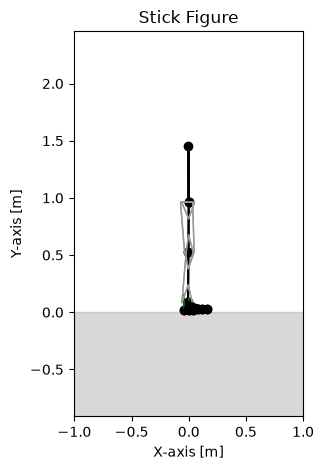

Saving results to result_HC/p1/huntcrossley_6spheres/standing.pkl
Best seed None: objective=1.0941503e-08, max residual=0.000389, status=0
Saved: result_HC/p1/huntcrossley_6spheres/standing.pkl
Saved seed comparison: result_HC/p1/huntcrossley_6spheres/standing_multistart.tsv


In [8]:
# Recompute the winner here from the latest trial list. This prevents a
# stale best_standing_guess from an earlier out-of-order notebook run.
latest_feasible = [item for item in multistart_results if item['feasible']]
if latest_feasible:
    best_standing_guess = min(latest_feasible, key=lambda item: item['objective'])
else:
    best_standing_guess = min(multistart_results, key=lambda item: (item['max_residual'], item['objective']))
best_seed = best_standing_guess['seed']
final_problem = build_seeded_problem(best_seed, save_output=True)
solution = final_problem.solve(visualize=True)
final_objective, final_residual, final_status, final_feasible = solution_metrics(final_problem, solution)
print(f'Best seed {best_seed}: objective={final_objective:.8g}, max residual={final_residual:.3g}, status={final_status}')
print('Saved:', OUTPUT_FILE.resolve())

log_file = OUTPUT_FILE.with_name('standing_multistart.tsv')
with log_file.open('w', encoding='utf-8') as handle:
    handle.write('seed\tobjective\tmax_residual\tstatus\tfeasible\n')
    for item in multistart_results:
        handle.write(f"{item['seed']}\t{item['objective']:.16g}\t{item['max_residual']:.16g}\t{item['status']}\t{item['feasible']}\n")
    handle.write(f'best_seed\t{best_seed}\n')
print('Saved seed comparison:', log_file.resolve())

Solved contact forces (N):
 [[8.67131427e-10 3.34695833e+02 0.00000000e+00]
 [8.66845645e-10 3.34696516e+02 0.00000000e+00]]


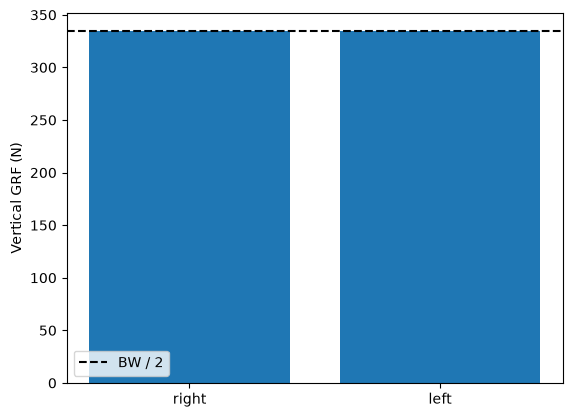

In [9]:
solved_state = calc_forces(solution.states[0], model)
solved_forces = np.asarray(solved_state.ext_forces).reshape(-1, 3)
labels = ['right', 'left']
plt.bar(labels, solved_forces[:, 1])
plt.axhline(float(model.default_constants.mass.sum() * 9.81 / 2), color='k', linestyle='--', label='BW / 2')
plt.ylabel('Vertical GRF (N)')
plt.legend();
print('Solved contact forces (N):\n', solved_forces)